# Manuscript visualizations

Run this notebook from top to bottom to generate **all six manuscript figures** and rebuild the manuscript. This is the only figure exporter in the project. It reads the same canonical records as `run_broadcast.ipynb`; it submits no jobs and collects no data.

Set the shared font size, palette, and export switches below. Each figure then has its own editable settings **and complete plotting code** in one cell. Run a figure cell again to preview that change; run the final cell to publish all figures. `record_table` lists the available measurements and their paths for changing source selections.

The figures appear in manuscript order: convergence, memory benchmark, circuit, QEC crossover, delay sweeps, hardware scaling. Output files go directly into `manuscript/`; source hashes and settings are saved beside them.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import json
import os
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import qiskit
from IPython.display import display

from broadcasting.analysis import delay_axis, hardware_scaling_points, joint_success_statistics, wilson_interval
from broadcasting.convergence import load_convergence
from broadcasting.circuit import generate_qiskit_circuit
from broadcasting.fidelity import add_fidelity
from broadcasting.results import RESULTS_DIR, list_runs
from broadcasting.simulation import logical_error_polynomial
from broadcasting.validation import dedupe_by_job

ROOT = Path.cwd().resolve()
if not (ROOT / "broadcasting").is_dir():
    raise RuntimeError("Run this notebook from the Broadcasting project root.")
MANUSCRIPT_DIR = ROOT / "manuscript"
SAVE_MANUSCRIPT_FIGURES = True
BUILD_MANUSCRIPT = True  # Run local LaTeX after all six PNGs have been exported.
SHOW_RECORD_TABLE = False

# Shared typography. Per-figure sizes and styles remain editable in the cells below.
FONT_SIZE = 11
AXIS_LABEL_FONT_SIZE = 10
LEGEND_FONT_SIZE = 7.5
INSET_FONT_SIZE = 7
SINGLE_FIGURE_SIZE = (4.4, 3.4)
DOUBLE_COLUMN_WIDTH = 7.2
PLOT_RC = {
    "figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": FONT_SIZE,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE, "axes.titlesize": FONT_SIZE, "axes.linewidth": 0.8,
    "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE, "legend.fontsize": LEGEND_FONT_SIZE,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "axes.spines.top": False, "axes.spines.right": False,
}
# Qiskit's circuit palette, shared by the circuit and all measured-data plots.
QISKIT_PALETTE = {
    "burgundy": "#9F1853", "cyan": "#33B1FF", "coral": "#FA4D56", "slate": "#778899",
}
EXPORT = dict(dpi=300, bbox_inches="tight", pad_inches=0.06,
              facecolor="white", transparent=False)

records = list_runs(ROOT / RESULTS_DIR)
records_by_path = defaultdict(list)
for run in records:
    records_by_path[Path(run["filepath"]).resolve()].append(run)
record_table = [{"record_id": run["record_id"], "kind": run["experiment_kind"],
                 "backend": run["backend"], "M": run["M"], "N": run["N"],
                 "encoded": run["use_qec"], "opt": run["optimization_level"],
                 "shots": run["shots"], "samples": run["n_samples"],
                 "axis": run["sweep"]["axis"], "points": len(run["sweep"]["values"]),
                 "path": str(Path(run["filepath"]).relative_to(ROOT))}
                for run in records]
print(f"Loaded {len(records)} records: {dict(Counter(run['experiment_kind'] for run in records))}")
if SHOW_RECORD_TABLE:
    display(record_table)

# These small notebook helpers handle selection, axes, and source evidence only.
# Every plotting call and every visual setting is in the figure's own cell.
def select_records(sources):
    # A multi-case job can be selected with {"path": "results/job.json", "record_id": "..."}.
    if sources is None:
        return records
    selected = []
    for source in sources:
        path = source["path"] if isinstance(source, dict) else source
        matches = records_by_path[(ROOT / path).resolve()]
        if isinstance(source, dict):
            matches = [run for run in matches if run["record_id"] == source["record_id"]]
        if len(matches) != 1:
            raise ValueError(f"Select one saved case with its path and record_id: {source}")
        selected.append(matches[0])
    return selected

def style_axis(ax, settings):
    properties = dict(settings["axes"])
    ax.set_xscale(properties.pop("xscale", "linear"))
    ax.set_yscale(properties.pop("yscale", "linear"))
    ax.set(**{key: value for key, value in properties.items() if value is not None})
    ax.grid(**settings["grid"])

def source_evidence(path):
    path = Path(path).resolve()
    return {"path": str(path.relative_to(ROOT)),
            "sha256": hashlib.sha256(path.read_bytes()).hexdigest()}

for previous_figure in globals().get("manuscript_figures", {}).values():
    plt.close(previous_figure)
manuscript_figures = {}
manuscript_sources = {}


Loaded 138 records: {'broadcasting': 133, 'memory': 5}


## Figure 1: Convergence

Separate receiver errors and totals for seeds 0–4. Seed 0 contains rounded error summaries; the other seeds retain their exact and sampled fidelity grids.

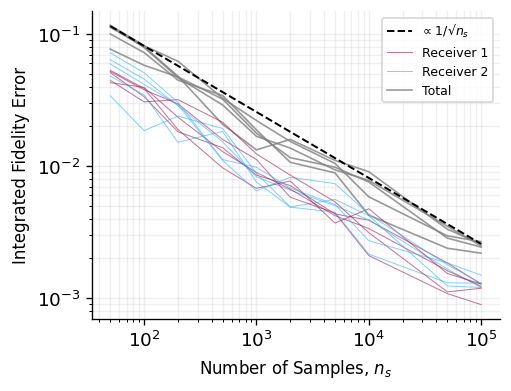

In [2]:
FIGURE_1 = {
    "filename": "figure_01_sampling_convergence.png", "figsize": SINGLE_FIGURE_SIZE,
    "results_dir": "results", "seed_zero_source": "results/run_seed_zero.json",
    "study_ids": None, "seeds": [1, 2, 3, 4],
    "show_seed_zero": True,
    # Apply the same component colors to every seed, including seed 0.
    "line_style": dict(linestyle="-", marker="", linewidth=0.6, alpha=0.6),
    "receiver_styles": [dict(color=QISKIT_PALETTE["burgundy"], label="Receiver 1"),
                        dict(color=QISKIT_PALETTE["cyan"], label="Receiver 2")],
    "total_style": dict(color="grey", label="Total", alpha=0.8, linewidth=1.0),
    "show_reference": True, "reference_exponent": -0.5,
    "reference_anchor_index": 0, "reference_multiplier": 1.0,
    "reference_style": dict(color="black", linestyle="--", marker="", linewidth=1.2, alpha=1,
                            label="∝ 1/√$n_s$"),
    "axes": dict(xlabel="Number of Samples, $n_s$",
                 ylabel="Integrated Fidelity Error",
                 xlim=None, ylim=None, xscale="log", yscale="log"),
    "grid": dict(visible=True, which="both", alpha=0.2),
    "legend": dict(loc="best", fontsize=LEGEND_FONT_SIZE, frameon=True),
    "layout": dict(pad=1.1),
}

with plt.rc_context(PLOT_RC):
    # Figure 1: receiver errors and their total for each saved seed, without pooling.
    cfg = FIGURE_1
    study = load_convergence(results_dir=ROOT / cfg["results_dir"],
                             seed_zero_path=ROOT / cfg["seed_zero_source"])
    repetitions = [rep for rep in study.repetitions
                   if (cfg["study_ids"] is None or rep["study_id"] in cfg["study_ids"])
                   and (cfg["seeds"] is None or rep["seed"] in cfg["seeds"])]
    if cfg["seeds"] is not None and set(cfg["seeds"]) - {rep["seed"] for rep in repetitions}:
        raise ValueError("Selected convergence seeds are missing from the saved results/studies.")
    fig1, ax1 = plt.subplots(figsize=cfg["figsize"])
    counts = np.asarray(study.sample_counts)
    seed_zero_errors = np.asarray(study.seed_zero["errors_per_receiver"])
    seed_zero_total = seed_zero_errors.sum(axis=1)
    component_styles = [*cfg["receiver_styles"], cfg["total_style"]]

    def _plot_convergence_components(x, errors, identity):
        errors = np.asarray(errors)
        if errors.shape != (len(x), 2) or len(cfg["receiver_styles"]) != 2:
            raise ValueError("Figure 1 requires two receiver errors at every saved sample count.")
        components = [errors[:, 0], errors[:, 1], errors.sum(axis=1)]
        for y, component_style in zip(components, component_styles):
            keep = y > 0 if cfg["axes"]["yscale"] == "log" else np.ones(len(y), dtype=bool)
            if not np.all(keep):
                print(f"Figure 1: omitted {np.sum(~keep)} zero-error point(s) on logarithmic y axis "
                      f"for {identity}, {component_style['label']}.")
            # Legend entries describe quantities; every seed remains a separate line.
            style = {**cfg["line_style"], **component_style, "label": "_nolegend_"}
            ax1.plot(np.asarray(x)[keep], y[keep], **style)

    convergence_paths = set()
    if cfg["show_seed_zero"] or cfg["show_reference"]:
        convergence_paths.add(ROOT / cfg["seed_zero_source"])
    if cfg["show_seed_zero"]:
        _plot_convergence_components(counts, seed_zero_errors, f"seed {study.config.seed}")
    for repetition in repetitions:
        points = repetition["points"]
        x = np.asarray([point["n_samples"] for point in points])
        errors = np.asarray([point["errors_per_receiver"] for point in points])
        _plot_convergence_components(x, errors, f"seed {repetition['seed']} ({repetition['study_id']})")
        if not repetition["complete"]:
            print(f"Figure 1: seed {repetition['seed']} ({repetition['study_id']}) is partial: {len(points)} saved counts.")
        convergence_paths.update(Path(point["path"]) for point in points)
    convergence_handles = []
    if cfg["show_reference"]:
        anchor = cfg["reference_anchor_index"]
        reference = cfg["reference_multiplier"] * seed_zero_total[anchor] * (counts / counts[anchor]) ** cfg["reference_exponent"]
        reference_line, = ax1.plot(counts, reference, **cfg["reference_style"])
        convergence_handles.append(reference_line)
    convergence_handles.extend(Line2D([], [], **{**cfg["line_style"], **style}) for style in component_styles)
    style_axis(ax1, cfg)
    ax1.legend(handles=convergence_handles, **cfg["legend"])
    fig1.tight_layout(**cfg["layout"])
    manuscript_figures[1] = fig1
    manuscript_sources[1] = [source_evidence(path) for path in sorted(convergence_paths)]


    display(fig1)
    plt.close(fig1)


## Figure 2: QEC memory benchmark

Four encoded/bare memory sweeps at optimization levels 0 and 3. These use the same result format as broadcasting.

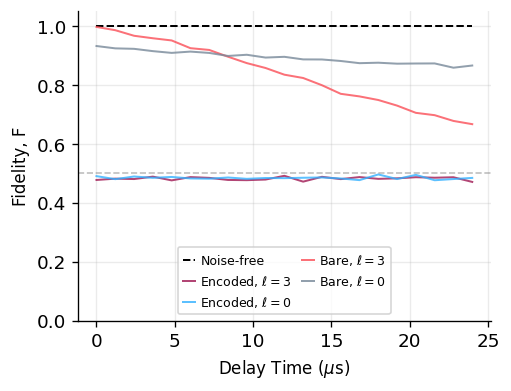

In [3]:
FIGURE_2 = {
    "filename": "figure_02_qec_memory.png", "figsize": SINGLE_FIGURE_SIZE,
    # Ordered: encoded opt3, encoded opt0, bare opt3, bare opt0.
    "sources": ["results/run_48c5255eac91a1784c73944f.json",
                "results/run_c9961cc71daa5d823a57cd68.json",
                "results/run_025ae13e0183f58f80e31d03.json",
                "results/run_2c91bf3308b84e88c880b308.json"],
    "data_styles": [dict(color=QISKIT_PALETTE["burgundy"], label="Encoded, $ℓ=3$"),
                    dict(color=QISKIT_PALETTE["cyan"], label="Encoded, $ℓ=0$"),
                    dict(color=QISKIT_PALETTE["coral"], label="Bare, $ℓ=3$"),
                    dict(color=QISKIT_PALETTE["slate"], label="Bare, $ℓ=0$")],
    "data_common": dict(linestyle="-", marker="", linewidth=1.2, alpha=0.8),
    "show_ideal": True,
    "ideal_style": dict(color="black", linestyle="--", marker="", linewidth=1.2, label="Noise-free"),
    "baseline": 0.5, "baseline_style": dict(color="gray", linestyle="--", linewidth=1, alpha=0.5),
    "xlabel": None,  # None uses the supported physical delay unit.
    "axes": dict(ylabel="Fidelity, F", xlim=None, ylim=(0, 1.05),
                 xscale="linear", yscale="linear"),
    "grid": dict(visible=True, alpha=0.25),
    "legend": dict(loc="lower center", ncol=2, fontsize=LEGEND_FONT_SIZE, frameon=True,
                   columnspacing=0.8, handlelength=1, handletextpad=0.4),
    "layout": dict(pad=1.1),
}

with plt.rc_context(PLOT_RC):
    # Figure 2: standalone memory benchmark, retaining each source's native delay grid.
    cfg = FIGURE_2
    memory_runs = select_records(cfg["sources"])
    if not memory_runs or len(memory_runs) != len(cfg["data_styles"]):
        raise ValueError("Figure 2 needs one data style for each memory source.")
    fig2, ax2 = plt.subplots(figsize=cfg["figsize"])
    scale, unit = delay_axis(memory_runs[0])
    if cfg["show_ideal"]:
        ax2.plot(scale * np.asarray(memory_runs[0]["tau_values"]),
                 np.asarray(memory_runs[0]["reference_fidelities"]["ideal"])[:, 0], **cfg["ideal_style"])
    for run, style in zip(memory_runs, cfg["data_styles"]):
        run_scale, run_unit = delay_axis(run)
        if run_unit != unit:
            raise ValueError("Figure 2 memory curves must use a common supported delay unit.")
        ax2.plot(run_scale * np.asarray(run["tau_values"]), np.asarray(run["fidelities"])[:, 0],
                 **{**cfg["data_common"], **style})
    if cfg["baseline"] is not None:
        ax2.axhline(cfg["baseline"], **cfg["baseline_style"])
    style_axis(ax2, cfg)
    ax2.set_xlabel(cfg["xlabel"] or (r"Delay Time ($\mu$s)" if unit == "us" else "Delay Time (dt)"))
    ax2.legend(**cfg["legend"])
    fig2.tight_layout(**cfg["layout"])
    manuscript_figures[2] = fig2
    manuscript_sources[2] = [source_evidence(run["filepath"]) for run in memory_runs]


    display(fig2)
    plt.close(fig2)


## Figure 3: Broadcasting circuit

Generated from the current circuit implementation using Qiskit. Circuit parameters, drawing style, fold width, and font sizes are editable here.

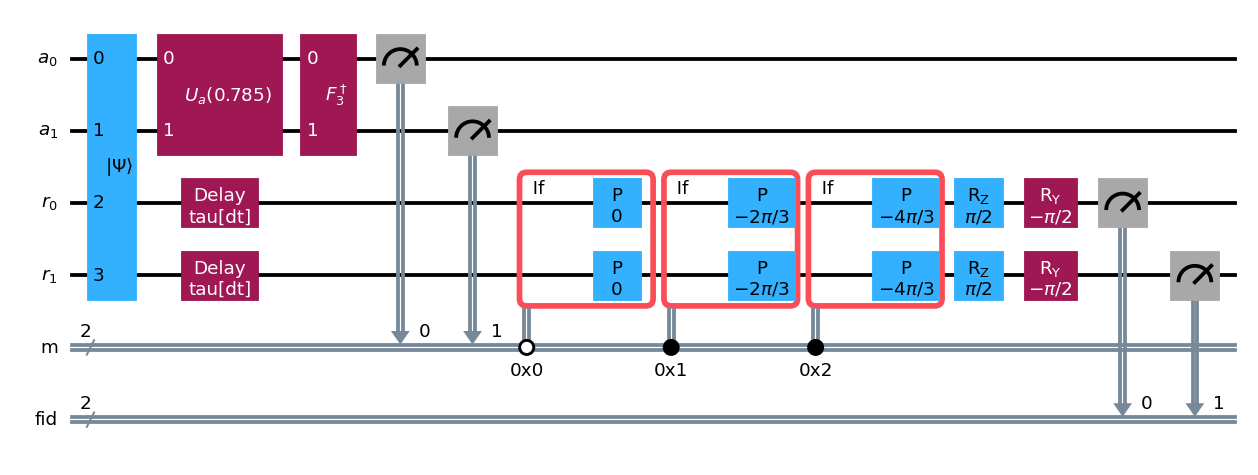

In [4]:
from qiskit import QuantumCircuit

FIGURE_3 = {
    'filename': 'figure_03_broadcast_circuit.png',
    'figsize': (13.8, 3.8),  # Wide canvas keeps every gate in one uninterrupted row.
    'M': 1, 'N': 2, 'thetas': [float(np.pi / 4)],
    'alpha': float(1 / np.sqrt(2)), 'tau': None, 'linear_feedforward': False,
    'margins': {'left': 0.01, 'right': 0.995, 'bottom': 0.005, 'top': 0.995},
    'draw_margin': [1.6, 0.15, 0.1, 0.15],
    'style': 'iqp', 'fold': -1, 'idle_wires': False, 'cregbundle': True,
    'resource_color': QISKIT_PALETTE['cyan'],
    'resource_text_color': '#000000',
    'resource_label': r'$|\Psi\rangle$',
    'sender_label': None,  # None labels each sender with its selected phase.
    'fourier_label': None,  # None uses the actual qudit dimension N+1.
}

with plt.rc_context(PLOT_RC):
    figure_3_source = generate_qiskit_circuit(
        M=FIGURE_3['M'], N=FIGURE_3['N'], thetas=FIGURE_3['thetas'],
        alphas=FIGURE_3['alpha'], tau=FIGURE_3['tau'],
        linear_feedforward=FIGURE_3['linear_feedforward'],
    )
    add_fidelity(figure_3_source, N=FIGURE_3['N'],
                 thetas=FIGURE_3['thetas'], alpha=FIGURE_3['alpha'])
    figure_3_drawing = figure_3_source.copy()
    sender_index = 0
    for index, item in enumerate(figure_3_drawing.data):
        if item.operation.name == 'initialize':
            resource = QuantumCircuit(len(item.qubits), name='resource')
            resource.append(item.operation, resource.qubits)
            figure_3_drawing.data[index] = item.replace(
                operation=resource.to_instruction(label=FIGURE_3['resource_label'])
            )
        elif item.operation.name == 'unitary':
            operation = item.operation.copy()
            if operation.label.startswith('Ua'):
                operation.label = FIGURE_3['sender_label'] or rf'$U_a({FIGURE_3["thetas"][sender_index]:.3g})$'
                sender_index += 1
            else:
                operation.label = FIGURE_3['fourier_label'] or rf'$F_{{{FIGURE_3["N"] + 1}}}^\dagger$'
            figure_3_drawing.data[index] = item.replace(operation=operation)

    circuit_style = {
        'name': FIGURE_3['style'], 'fontsize': FONT_SIZE, 'subfontsize': FONT_SIZE,
        'margin': FIGURE_3['draw_margin'],
        'displaycolor': {'resource': (FIGURE_3['resource_color'], FIGURE_3['resource_text_color'])},
    }
    figure_3, circuit_ax = plt.subplots(figsize=FIGURE_3['figsize'])
    figure_3.subplots_adjust(**FIGURE_3['margins'])
    figure_3_drawing.draw(output='mpl', ax=circuit_ax, fold=FIGURE_3['fold'], style=circuit_style,
                          idle_wires=FIGURE_3['idle_wires'], cregbundle=FIGURE_3['cregbundle'])
    for text in circuit_ax.texts:
        text.set_fontsize(FONT_SIZE)

    assert figure_3_drawing.data[0].operation.definition.data[0].operation == figure_3_source.data[0].operation

    manuscript_figures[3] = figure_3
    manuscript_sources[3] = [source_evidence(ROOT / path) for path in
                             ["broadcasting/circuit.py", "broadcasting/fidelity.py", "broadcasting/state_preparation.py"]]
    display(figure_3)
    plt.close(figure_3)


## Figure 4: QEC crossover

Each simulation keeps its native probability grid. Analytical curves can be enabled with `show_theory`.

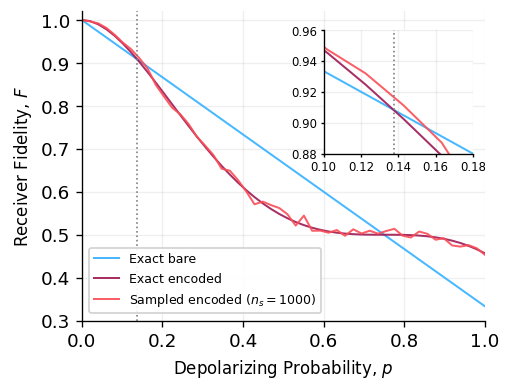

In [5]:
FIGURE_4 = {
    "filename": "figure_04_qec_crossover.png", "figsize": SINGLE_FIGURE_SIZE,
    # Ordered: exact bare, exact encoded, sampled encoded. Each retains its native p grid.
    "sources": ["results/run_a5e7cf640b46986ea6c0aee3.json", "results/run_6970dd796640cbdec866d2e2.json",
                "results/run_bb4881e0e309e98f6181006f.json"],
    "theory_p_range": (0, 1), "theory_points": 500,
    "show_theory": False,
    "bare_theory": dict(color="black", linestyle="--", linewidth=1.1, label="Bare theory"),
    "encoded_theory": dict(color=QISKIT_PALETTE["burgundy"], linestyle="-", linewidth=1.3, label="Encoded theory"),
    "data_styles": [dict(marker="", color=QISKIT_PALETTE["cyan"], label="Exact bare"),
                    dict(marker="", color=QISKIT_PALETTE["burgundy"], label="Exact encoded"),
                    dict(marker="", color=QISKIT_PALETTE["coral"], label="Sampled encoded ($n_s={n_samples}$)")],
    "data_common": dict(linestyle="-", markersize=3.5, alpha=0.9),
    "show_crossover": True, "crossover_style": dict(color="0.5", linestyle=":", linewidth=1),
    "show_inset": True, "inset_bounds": [0.60, 0.54, 0.37, 0.40],
    "inset_axes": dict(xlim=(0.1, 0.18), ylim=(0.88, 0.96)),
    "inset_ticks": dict(axis="both", labelsize=INSET_FONT_SIZE, length=2, pad=2),
    "inset_xticks": [0.10, 0.12, 0.14, 0.16, 0.18],
    "inset_yticks": [0.88, 0.90, 0.92, 0.94, 0.96],
    "axes": dict(xlabel="Depolarizing Probability, $p$", ylabel="Receiver Fidelity, $F$",
                xlim=(0, 1), ylim=(0.3, 1.02), xscale="linear", yscale="linear"),
    "grid": dict(visible=True, alpha=0.2),
    "legend": dict(loc="lower left", fontsize=LEGEND_FONT_SIZE, frameon=True,
                   framealpha=0.9, borderaxespad=0.6),
    "layout": dict(pad=1.1),
}

with plt.rc_context(PLOT_RC):
    # Figure 4: exact and sampled crossover curves on their own saved grids.
    cfg = FIGURE_4
    crossover_runs = select_records(cfg["sources"])
    if len(crossover_runs) != 3 or len(cfg["data_styles"]) != 3:
        raise ValueError("Figure 4 needs exact bare, exact encoded, and sampled encoded sources/styles.")
    for run, qec, backend in zip(crossover_runs, [False, True, True], ["aer_exact", "aer_exact", "aer_sampling"]):
        if ((run["M"], run["N"], run["sweep"]["axis"]) != (1, 2, "p")
                or run["use_qec"] != qec or run["backend"] != backend
                or not np.isclose(run["alpha"], crossover_runs[0]["alpha"])
                or not np.allclose(run["theta_samples"], crossover_runs[0]["theta_samples"])):
            raise ValueError("Figure 4 sources must have matching protocol/target settings and the stated simulation modes.")
    fig4, ax4 = plt.subplots(figsize=cfg["figsize"])
    inset4 = ax4.inset_axes(cfg["inset_bounds"]) if cfg["show_inset"] else None
    p = np.linspace(*cfg["theory_p_range"], cfg["theory_points"])
    for ax in [ax4] + ([inset4] if inset4 is not None else []):
        if cfg["show_theory"]:
            ax.plot(p, 1 - 2 * p / 3, **cfg["bare_theory"])
            ax.plot(p, 1 - 2 * logical_error_polynomial(p) / 3, **cfg["encoded_theory"])
        for run, style in zip(crossover_runs, cfg["data_styles"]):
            style = {**cfg["data_common"], **style}
            style["label"] = style["label"].replace("{n_samples}", str(run.get("n_samples")))
            ax.plot(run["sweep"]["values"], np.asarray(run["fidelities"]).mean(axis=1), **style)
        if cfg["show_crossover"]:
            ax.axvline((3 - np.sqrt(6)) / 4, **cfg["crossover_style"])
        ax.grid(**cfg["grid"])
    style_axis(ax4, cfg)
    if inset4 is not None:
        inset4.set(**cfg["inset_axes"])
        inset4.set_xticks(cfg["inset_xticks"])
        inset4.set_yticks(cfg["inset_yticks"])
        inset4.tick_params(**cfg["inset_ticks"])
    ax4.legend(**cfg["legend"])
    fig4.tight_layout(**cfg["layout"])
    manuscript_figures[4] = fig4
    manuscript_sources[4] = [source_evidence(run["filepath"]) for run in crossover_runs]


    display(fig4)
    plt.close(fig4)


## Figure 5: Receiver fidelity versus delay

Three Marrakesh runs on the left and three Kingston runs on the right. Each run retains both receivers and its own mean; the legend identifies quantities.

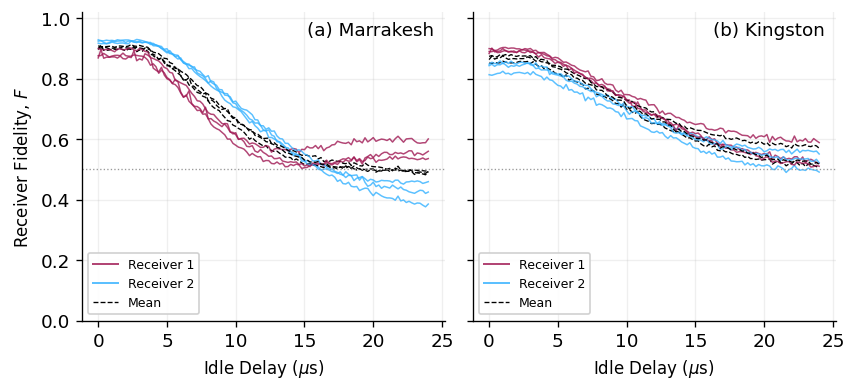

In [6]:
FIGURE_5 = {
    "filename": "figure_05_delay_repeats.png", "panel_backends": ["ibm_marrakesh", "ibm_kingston"],
    "panel_size": (DOUBLE_COLUMN_WIDTH / 2, 3.4),
    "sharey": True,
    # Three 121-point opt3 sweeps per backend, in repeat order within each panel.
    "sources": ["results/job_132048dd9bb34e83b92f8bd556a82d39_repeat_000.json",
                "results/job_132048dd9bb34e83b92f8bd556a82d39_repeat_001.json",
                "results/job_132048dd9bb34e83b92f8bd556a82d39_repeat_002.json",
                "results/job_5bfbc6524097416e8c6642cc0568c656_repeat_000.json",
                "results/job_5bfbc6524097416e8c6642cc0568c656_repeat_001.json",
                "results/job_5bfbc6524097416e8c6642cc0568c656_repeat_002.json"],
    "receiver_colors": [QISKIT_PALETTE["burgundy"], QISKIT_PALETTE["cyan"]],
    "receiver_style": dict(marker="", linewidth=0.9, alpha=0.8),
    # Styles are assigned within each backend panel, in source-list order.
    "run_styles": [dict(linestyle="-"), dict(linestyle="-"), dict(linestyle="-")],
    "receiver_label": "Receiver {receiver}",
    "show_intervals": False, "confidence": 0.95, "interval_style": dict(alpha=0.18, linewidth=0),
    "show_mean": True, "mean_style": dict(color="black", marker="", linewidth=0.8, alpha=1, label="Mean", linestyle="--"),
    "baseline": 0.5, "baseline_style": dict(color="0.6", marker="", linestyle=":", linewidth=0.8, alpha=1),
    # None uses the archived dt conversion (microseconds), or native dt if unknown.
    "xlabel": None,
    "axes": dict(ylabel="Receiver Fidelity, $F$", xlim=None, ylim=(0, 1.02), xscale="linear", yscale="linear"),
    "panel_label": "({letter}) {backend}",
    "panel_text": dict(x=0.97, y=0.97, fontsize=FONT_SIZE, va="top", ha="right"),
    "grid": dict(visible=True, alpha=0.2),
    "legend": dict(loc="lower left", ncol=1, frameon=True, framealpha=0.9, fontsize=LEGEND_FONT_SIZE),
    "layout": dict(pad=1.1, w_pad=1.2),
}

with plt.rc_context(PLOT_RC):
    # Figure 5: overlay each backend's saved sweeps in its own panel.
    cfg = FIGURE_5
    delay_runs = dedupe_by_job(select_records(cfg["sources"]))
    traces = []
    for run in delay_runs:
        if (run["experiment_type"] != "hardware" or run.get("optimization_level") != 3
                or (run["M"], run["N"]) != (1, 2) or run.get("use_qec")
                or run["sweep"]["axis"] != "tau" or len(run["sweep"]["values"]) < 2 or not run.get("counts")):
            raise ValueError(f"Figure 5 needs unencoded opt3 M=1,N=2 delay records with counts: {run['filename']}")
        traces.extend((run, i, row) for i, row in enumerate(run["counts"]))
    panel_backends = cfg["panel_backends"]
    if len(panel_backends) != 2 or set(panel_backends) != {run["backend"] for run in delay_runs}:
        raise ValueError("Figure 5 needs two backend panels covering every selected source.")
    panel_traces = [[trace for trace in traces if trace[0]["backend"] == backend]
                    for backend in panel_backends]
    if not cfg["run_styles"] or any(len(group) > len(cfg["run_styles"]) for group in panel_traces):
        raise ValueError("Add a distinct run_style for every overlaid sweep in the largest panel.")
    fig5, axes5 = plt.subplots(1, 2, squeeze=False, sharey=cfg["sharey"],
                              figsize=(2 * cfg["panel_size"][0], cfg["panel_size"][1]))
    for panel_index, (ax, backend, group) in enumerate(zip(axes5.flat, panel_backends, panel_traces)):
        if len({delay_axis(run)[1] for run, _, _ in group}) != 1:
            raise ValueError(f"Cannot overlay known physical times and unknown native dt for {backend}.")
        for run_index, (run, theta_index, counts) in enumerate(group):
            run_style = cfg["run_styles"][run_index]
            scale, unit = delay_axis(run)
            order = np.argsort(run["sweep"]["values"])
            tau = scale * np.asarray(run["sweep"]["values"])[order]
            stats = [joint_success_statistics(counts[i], run["N"]) for i in order]
            local = np.asarray([item["local_fidelities"] for item in stats])
            for receiver in range(run["N"]):
                color = cfg["receiver_colors"][receiver % len(cfg["receiver_colors"])]
                ax.plot(tau, local[:, receiver], color=color,
                        label=cfg["receiver_label"].format(receiver=receiver + 1),
                        **{**cfg["receiver_style"], **run_style})
                if cfg["show_intervals"]:
                    ci = np.asarray([wilson_interval(item["local_fidelities"][receiver] * item["shots"],
                                                    item["shots"], cfg["confidence"]) for item in stats])
                    ax.fill_between(tau, ci[:, 0], ci[:, 1], color=color, **cfg["interval_style"])
            if cfg["show_mean"]:
                ax.plot(tau, local.mean(axis=1), **{**run_style, **cfg["mean_style"], "marker": ""})
        if cfg["baseline"] is not None:
            ax.axhline(cfg["baseline"], **cfg["baseline_style"])
        label = cfg["panel_label"].format(letter=chr(97 + panel_index), backend=backend.removeprefix("ibm_").title())
        ax.text(s=label, transform=ax.transAxes, **cfg["panel_text"])
        style_axis(ax, cfg)
        if panel_index > 0:
            ax.set_ylabel("")
        ax.set_xlabel(cfg["xlabel"] or (r"Idle Delay ($\mu$s)" if unit == "us" else "Idle Delay (dt)"))
    receiver_handles = [Line2D([], [], color=color, linestyle="-", marker="", alpha=cfg["receiver_style"]["alpha"],
                               label=cfg["receiver_label"].format(receiver=i + 1))
                        for i, color in enumerate(cfg["receiver_colors"][:2])]
    if cfg["show_mean"]:
        receiver_handles.append(Line2D([], [], **cfg["mean_style"]))
    for ax in axes5.flat:
        ax.legend(handles=receiver_handles, **cfg["legend"])
    fig5.tight_layout(**cfg["layout"])
    manuscript_figures[5] = fig5
    manuscript_sources[5] = [source_evidence(run["filepath"]) for run in delay_runs]


    display(fig5)
    plt.close(fig5)


## Figure 6: Hardware scaling

Every eligible unencoded, optimization-level-3, zero-delay broadcasting observation is included. Bars span receiver minimum–maximum; offsets only separate points visually.

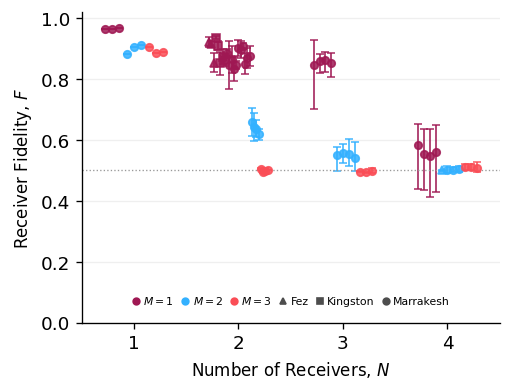

In [7]:
FIGURE_6 = {
    "filename": "figure_06_hardware_scaling.png", "figsize": SINGLE_FIGURE_SIZE,
    # None selects every eligible unencoded, opt3, zero-delay record, regardless of origin.
    "sources": None,
    "sender_colors": {1: QISKIT_PALETTE["burgundy"], 2: QISKIT_PALETTE["cyan"], 3: QISKIT_PALETTE["coral"]},
    "backend_markers": {"ibm_kingston": "s", "ibm_fez": "^", "ibm_marrakesh": "o"},
    "fallback_colors": [QISKIT_PALETTE["slate"], QISKIT_PALETTE["coral"], QISKIT_PALETTE["cyan"]],
    "fallback_markers": ["D", "v", "P", "X"],
    "horizontal_spread": 0.56,  # Full width around each integer N; zero disables offsets.
    "show_receiver_range": True,
    "point_style": dict(markersize=4.5, capsize=2.5, linewidth=1.1, alpha=0.85, linestyle="none"),
    "sender_label": "$M={sender}$", "backend_label": "{backend}",
    "backend_legend_color": "0.3",
    "baseline": 0.5, "baseline_style": dict(color="0.6", linestyle=":", linewidth=0.8),
    "axes": dict(xlabel="Number of Receivers, $N$", ylabel="Receiver Fidelity, $F$",
                 xlim=None, ylim=(0, 1.02), xscale="linear", yscale="linear"),
    "xticks": None,  # None uses the integer receiver counts.
    "grid": dict(visible=True, axis="y", alpha=0.2),
    "legend": dict(loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=6, frameon=False, fontsize=LEGEND_FONT_SIZE - 1,
                   columnspacing=0.6, handlelength=0.8, handletextpad=0.3),
    "layout": dict(pad=1.1),
}

with plt.rc_context(PLOT_RC):
    # Figure 6: one point per observation; the range is across receivers, not repeats.
    cfg = FIGURE_6
    scaling_runs = select_records(cfg["sources"])
    scaling_points = hardware_scaling_points(scaling_runs)
    if not scaling_points:
        raise ValueError("No saved opt3 zero-delay observations for Figure 6.")
    senders = sorted({point["M"] for point in scaling_points})
    backends = sorted({point["backend"] for point in scaling_points})
    receivers = sorted({point["N"] for point in scaling_points})
    colors = {m: cfg["sender_colors"].get(m, cfg["fallback_colors"][i % len(cfg["fallback_colors"])])
              for i, m in enumerate(senders)}
    markers = {b: cfg["backend_markers"].get(b, cfg["fallback_markers"][i % len(cfg["fallback_markers"])])
               for i, b in enumerate(backends)}
    fig6, ax6 = plt.subplots(figsize=cfg["figsize"])
    for n in receivers:
        group = [point for point in scaling_points if point["N"] == n]
        offsets = np.linspace(-cfg["horizontal_spread"] / 2, cfg["horizontal_spread"] / 2, len(group)) if len(group) > 1 else [0]
        for point, offset in zip(group, offsets):
            point["x"] = float(n + offset)
            mean = point["mean"]
            error = [[max(0, mean - point["minimum"])], [max(0, point["maximum"] - mean)]]
            ax6.errorbar(point["x"], mean, yerr=error if cfg["show_receiver_range"] else None,
                         marker=markers[point["backend"]], color=colors[point["M"]], **cfg["point_style"])
    handles = [Line2D([], [], color=colors[m], marker="o", linestyle="none",
                      label=cfg["sender_label"].format(sender=m)) for m in senders]
    handles += [Line2D([], [], color=cfg["backend_legend_color"], marker=markers[b], linestyle="none",
                       label=cfg["backend_label"].format(backend=b.removeprefix("ibm_").title())) for b in backends]
    ax6.legend(handles=handles, **cfg["legend"])
    style_axis(ax6, cfg)
    ax6.set_xticks(cfg["xticks"] if cfg["xticks"] is not None else range(min(receivers), max(receivers) + 1))
    if cfg["axes"]["xlim"] is None:
        ax6.set_xlim(min(receivers) - 0.5, max(receivers) + 0.5)
    if cfg["baseline"] is not None:
        ax6.axhline(cfg["baseline"], **cfg["baseline_style"])
    fig6.tight_layout(**cfg["layout"])
    fig6.broadcasting_points = scaling_points
    manuscript_figures[6] = fig6
    eligible_runs = [run for run in dedupe_by_job(scaling_runs) if hardware_scaling_points([run])]
    manuscript_sources[6] = [source_evidence(path) for path in sorted({run["filepath"] for run in eligible_runs})]


    display(fig6)
    plt.close(fig6)


## Export to the manuscript

The six PNGs, source manifest, and compiled manuscript are refreshed together. For previews, set `SAVE_MANUSCRIPT_FIGURES=False`. To export PNGs without running LaTeX, set `BUILD_MANUSCRIPT=False`.

In [8]:
# Exports are written only here, after every figure has rendered successfully.
figure_settings = {1: FIGURE_1, 2: FIGURE_2, 3: FIGURE_3, 4: FIGURE_4, 5: FIGURE_5, 6: FIGURE_6}
if set(manuscript_figures) != set(figure_settings):
    raise RuntimeError("Run all six figure cells before exporting the manuscript.")
if SAVE_MANUSCRIPT_FIGURES:
    MANUSCRIPT_DIR.mkdir(exist_ok=True)
    for number in sorted(manuscript_figures):
        path = MANUSCRIPT_DIR / figure_settings[number]["filename"]
        manuscript_figures[number].savefig(path, format="png", **EXPORT)
        print(f"Figure {number}: {path.relative_to(ROOT)}")
    provenance = {"schema_version": 2, "generator": "visualizations.ipynb",
                  "palette": QISKIT_PALETTE, "rc_params": PLOT_RC, "export": EXPORT,
                  "qiskit_version": qiskit.__version__,
                  "figures": {str(n): {"settings": figure_settings[n], "sources": manuscript_sources[n]}
                              for n in figure_settings}, "scaling_points": scaling_points}
    (MANUSCRIPT_DIR / "figure_sources.json").write_text(json.dumps(provenance, indent=2) + "\n")

    if BUILD_MANUSCRIPT:
        if not shutil.which("pdflatex") or not shutil.which("bibtex"):
            raise RuntimeError("PNGs exported. Install pdflatex and bibtex, or set BUILD_MANUSCRIPT=False.")
        # Isolate LaTeX intermediates so editor auto-builds cannot corrupt this build.
        with tempfile.TemporaryDirectory(prefix="broadcast-manuscript-") as directory:
            build = Path(directory)
            command = ["pdflatex", "-interaction=nonstopmode", "-halt-on-error",
                       "-jobname=manuscript", f"-output-directory={build}", "apstemplate.tex"]
            commands = [(command, MANUSCRIPT_DIR, None),
                        (["bibtex", "manuscript"], build,
                         {**os.environ, "BIBINPUTS": str(MANUSCRIPT_DIR) + os.pathsep}),
                        (command, MANUSCRIPT_DIR, None), (command, MANUSCRIPT_DIR, None)]
            for arguments, directory, environment in commands:
                completed = subprocess.run(arguments, cwd=directory, env=environment,
                                           capture_output=True, text=True)
                if completed.returncode:
                    raise RuntimeError("Manuscript build failed:\n" + completed.stdout[-6000:] + completed.stderr[-1000:])
            # Publish the completed PDF atomically, alongside the exported PNGs.
            target = MANUSCRIPT_DIR / "apstemplate.pdf"
            with tempfile.NamedTemporaryFile(dir=MANUSCRIPT_DIR, suffix=".pdf", delete=False) as handle:
                handle.write((build / "manuscript.pdf").read_bytes())
                temporary = Path(handle.name)
            os.replace(temporary, target)
            print(f"Built {target.relative_to(ROOT)}")
else:
    print("Preview only; figures and manuscript were not written.")


Figure 1: manuscript/figure_01_sampling_convergence.png
Figure 2: manuscript/figure_02_qec_memory.png
Figure 3: manuscript/figure_03_broadcast_circuit.png
Figure 4: manuscript/figure_04_qec_crossover.png
Figure 5: manuscript/figure_05_delay_repeats.png
Figure 6: manuscript/figure_06_hardware_scaling.png
Built manuscript/apstemplate.pdf
